# 06_特征选择方法-互信息法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今来聊聊互信息法\~

在机器学习中，我们通常会有很多特征（即数据的列），而不是所有的特征都对模型的预测结果有帮助。

特征选择的目标就是从这些特征中挑选出对模型最有用的特征，这样可以减少计算量、提高模型效果、避免过拟合等问题。

**那么，今天要聊的互信息法是什么？**

互信息法（Mutual Information，MI）是一种用来评估特征和目标变量（也叫标签）之间关系强弱的方式。

简单来说，它是用来衡量**两个变量之间有多少“信息”是共享的**。如果一个特征和目标变量之间的信息共享越多，说明这个特征对预测目标变量越有用。

#### 直观理解

想象一下，你在猜一个秘密（目标变量），然后你有一些线索（特征）。互信息法就像是在告诉你，这些线索（特征）能帮助你多大程度上猜到这个秘密（目标变量）。如果一个特征能让你更好地猜到目标变量，那它就是有用的。如果它基本上对目标没有影响，那么它就不是很有用。

#### 互信息的计算

互信息的计算公式是基于**信息论**的。我们用信息熵（entropy）来衡量一个变量的不确定性，然后通过计算**联合熵**和**单独熵**之间的差异，来评估它们之间的“信息共享”程度。

**简单一点讲：**

- 如果两个变量的值完全相关（比如它们都随着同一个模式变化），那么它们之间的互信息就很高。
- 如果两个变量之间几乎没有关系（它们变化没有规律可循），那么它们的互信息就很低。

#### 为什么要用互信息法？

1. **不依赖数据分布**：和一些传统方法（比如皮尔逊相关系数）不同，互信息法不需要数据符合特定的分布，比如正态分布。
2. **能够捕捉非线性关系**：它不仅能检测到线性关系，还能捕捉到变量之间的非线性关系。比如有些特征之间的关系可能不是简单的直线关系，但互信息法能发现这种关系。

总的来说，互信息法就是通过测量特征和目标变量之间信息的重叠程度，来帮助我们选择对预测最有帮助的特征。如果两个变量有很多共享的信息，说明它们是相关的，特征就可能对预测有帮助；如果它们的共享信息很少，说明这个特征可能对目标预测没什么帮助。

## 原理详解

### 1. 信息论基础

首先，我们要明白互信息法是基于**信息论**的思想。

信息论的核心概念包括：

- **信息熵（Entropy）**：用来衡量一个随机变量的不确定性或信息量。
- 对于离散随机变量 $X$的信息熵，定义为：  
$H(X) = - \sum_{x \in X} P(x) \log P(x)$  
其中，$P(x)$是 $X$取某个值 $x$的概率，$H(X)$表示 $X$的不确定性。
- **条件熵（Conditional Entropy）**：表示在已知某个变量 $Y$的情况下，变量 $X$的不确定性。即，给定 $Y$后，$X$的信息熵：  
$H(X|Y) = - \sum_{y \in Y} P(y) \sum_{x \in X} P(x|y) \log P(x|y)$  
这里，$P(x|y)$是在给定 $Y = y$的情况下，$X = x$的条件概率。
- **联合熵（Joint Entropy）**：表示两个变量 $X$和 $Y$一起的熵，衡量了 $X$和 $Y$的联合不确定性：  
$H(X, Y) = - \sum_{x \in X} \sum_{y \in Y} P(x, y) \log P(x, y)$  
其中，$P(x, y)$是 $X$和 $Y$同时取值为 $(x, y)$的联合概率。

### 2. 互信息（Mutual Information）

互信息（MI）衡量的是两个变量之间的信息共享量。

简单来说，互信息越大，两个变量之间的关系越强，它们所包含的信息越相似。

互信息的数学定义是：  
$I(X; Y) = H(X) + H(Y) - H(X, Y)$  
即，两个变量 $X$和 $Y$的互信息 $I(X; Y)$等于它们的单独信息熵之和，减去它们的联合信息熵。

**推导过程：**

1. **信息熵的定义**：首先根据信息熵的定义，$X$和 $Y$的熵分别是：  
$H(X) = - \sum_{x \in X} P(x) \log P(x)$  
$H(Y) = - \sum_{y \in Y} P(y) \log P(y)$
2. **联合熵的定义**：联合熵是 $X$和 $Y$一起的熵，定义为：  
$H(X, Y) = - \sum_{x \in X} \sum_{y \in Y} P(x, y) \log P(x, y)$
3. **互信息的公式**：根据互信息的定义，将信息熵和联合熵代入得：  
$I(X; Y) = H(X) + H(Y) - H(X, Y)$  
这个公式表明，互信息等于单独的熵减去联合熵。

### 3. 互信息与特征选择

在特征选择中，我们的目标是选择与目标变量（标签）具有最大互信息的特征。

假设我们有一个目标变量 $Y$和一组特征 $X_1, X_2, \dots, X_n$，我们想要选择那些和 $Y$互信息最大（即最相关）的特征。

### 4. 互信息法的特征选择过程

互信息法的特征选择流程大致如下：

1. **计算特征与目标变量之间的互信息**：  
对于每一个特征 $X_i$和目标变量 $Y$，计算互信息 $I(X_i; Y)$。这可以通过以下步骤来实现：

   - **计算** $X_i$**和** $Y$**的信息熵** $H(X_i)$和 $H(Y)$。
   - **计算联合熵** $H(X_i, Y)$，即特征 $X_i$和目标变量 $Y$的联合信息熵。
   - 使用公式 $I(X_i; Y) = H(X_i) + H(Y) - H(X_i, Y)$计算每个特征与目标的互信息。
2. **选择互信息最大的特征**：  
计算所有特征和目标变量的互信息后，我们选择互信息值最高的特征。互信息值越高，意味着该特征和目标变量之间的关系越强，对预测目标变量更有帮助。
3. **筛选特征**：  
根据设定的阈值，或者通过选择排名前 K 的特征（根据互信息的大小），来选择最终的特征子集。

### 5. 互信息的估计方法

在实际应用中，由于我们通常面对的是有限的数据集，因此需要对互信息进行估计。

一些常用的互信息估计方法：

1. **离散化法**：将连续特征离散化为若干类别，之后计算互信息。
2. **基于直方图的估计**：通过构建数据的概率密度直方图来估计熵和联合熵。
3. **K近邻估计法**：利用 K 近邻算法估计概率密度，进而计算熵和互信息。

互信息法在特征选择中的关键在于如何计算互信息，并且在面对高维数据时需要有效地估计概率分布。

通过提到的这些方法，能够有效地提高模型的性能，减少冗余特征，提高计算效率。

## 完整案例

我们使用一个模拟数据集，该数据集包含一些与健康状况相关的特征，如年龄、体重、身高、饮食习惯、运动频率等。

目标变量是一个二分类标签，表示该人是否患有某种疾病。

### 目标

- 使用互信息法进行特征选择。
- 通过可视化展示特征选择的过程。
- 使用交叉验证优化模型。

### 数据集构建

我们将构建一个虚拟的数据集，使用`pandas`和`numpy`生成数据。该数据集将包含以下特征：

- `age`（年龄）
- `height`（身高）
- `weight`（体重）
- `diet`（饮食习惯，分类变量）
- `exercise`（运动频率，分类变量）
- `health_status`（健康状况，目标变量）

### 代码实现

包括数据生成、特征选择、模型训练与优化、可视化分析等步骤。

Dataset preview:
   age  height  weight     diet exercise  health_status
0   56     160      92     Good     None              1
1   69     170      69  Average     High              0
2   46     175      78     Poor     High              1
3   32     174      70     Good     None              1
4   60     171      41     Poor     High              1

Mutual Information of features:
    Feature  Mutual Information
2    weight            0.013083
0       age            0.011692
1    height            0.000000
3      diet            0.000000
4  exercise            0.000000


/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11496/2894166813.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mutual Information', y='Feature', data=mi_df, palette='Set2')


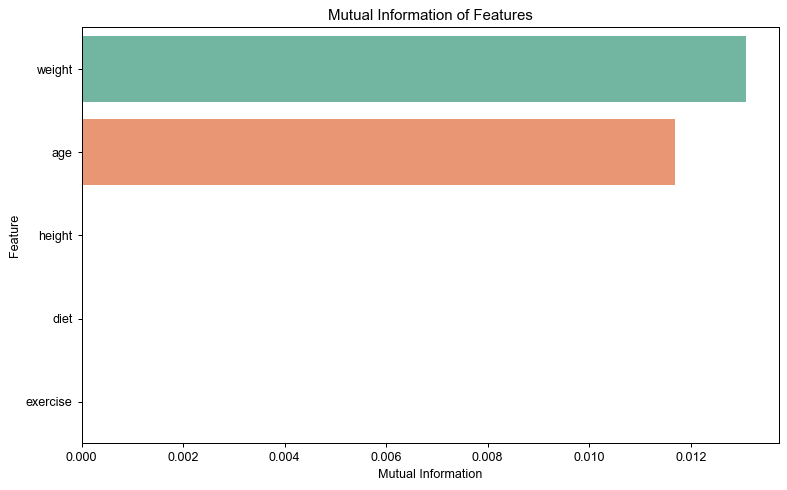

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

np.random.seed(42)

# 1. 构建虚拟数据集
def create_dataset():
    # 随机生成数据
    n_samples = 1000
    age = np.random.randint(18, 80, size=n_samples)
    height = np.random.randint(150, 200, size=n_samples)
    weight = np.random.randint(40, 120, size=n_samples)
    diet = np.random.choice(['Good', 'Average', 'Poor'], size=n_samples)
    exercise = np.random.choice(['None', 'Low', 'High'], size=n_samples)
    
    # 生成目标变量 health_status (0 = 健康, 1 = 患病)
    health_status = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])
    
    # 将数据组织为一个DataFrame
    df = pd.DataFrame({
        'age': age,
        'height': height,
        'weight': weight,
        'diet': diet,
        'exercise': exercise,
        'health_status': health_status
    })
    
    return df

# 创建数据集
df = create_dataset()

# 2. 数据预处理

# 显示数据集的前几行
print("Dataset preview:")
print(df.head())

# 将分类变量转化为数值型变量
label_encoder = LabelEncoder()
df['diet'] = label_encoder.fit_transform(df['diet'])
df['exercise'] = label_encoder.fit_transform(df['exercise'])

# 将特征与目标分开
X = df.drop('health_status', axis=1)
y = df['health_status']

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 计算互信息（Mutual Information）

# 计算互信息
mi = mutual_info_classif(X_scaled, y)

# 将互信息与特征对应
mi_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mi})

# 按互信息值排序
mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)

# 显示互信息排序结果
print("\nMutual Information of features:")
print(mi_df)

# 4. 特征选择：选择互信息最大的特征

# 可视化互信息
plt.figure(figsize=(10, 6))
sns.barplot(x='Mutual Information', y='Feature', data=mi_df, palette='Set2')
plt.title('Mutual Information of Features')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.show()


Top 3 most relevant features: ['weight' 'age' 'height']

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       151
           1       0.26      0.16      0.20        49

    accuracy                           0.68       200
   macro avg       0.51      0.51      0.50       200
weighted avg       0.64      0.68      0.65       200



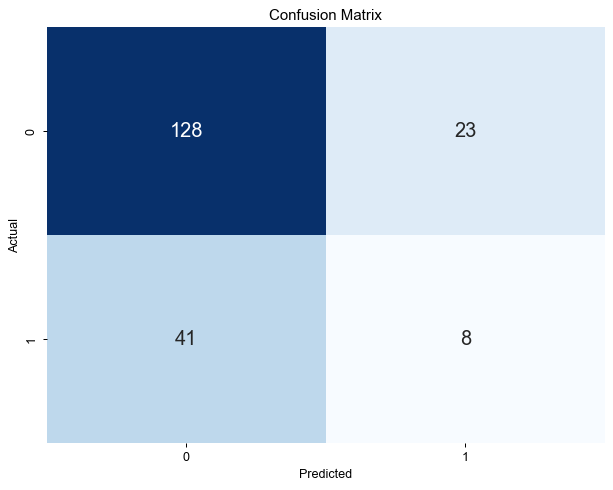


Cross-validation scores: [0.7   0.685 0.67  0.715 0.69 ]
Mean cross-validation score: 0.692
Fitting 5 folds for each of 8 candidates, totalling 40 fits



Best parameters from GridSearchCV: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Optimized Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.99      0.86       151
           1       0.00      0.00      0.00        49

    accuracy                           0.75       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.57      0.75      0.65       200



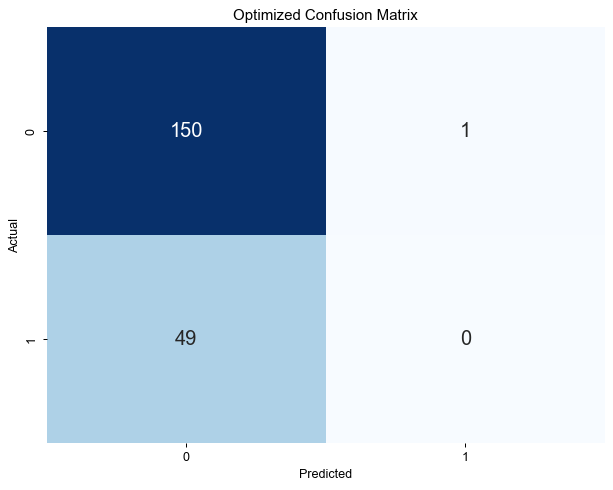

In [3]:
# 根据互信息选择最重要的特征
top_features = mi_df['Feature'].head(3).values  # 选择前3个最相关的特征
print("\nTop 3 most relevant features:", top_features)

# 根据互信息选择特征
X_selected = X[top_features]

# 5. 数据集拆分

# 拆分数据集为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# 6. 模型训练与评估

# 训练一个随机森林分类器
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 模型预测
y_pred = model.predict(X_test)

# 输出模型评估报告
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 交叉验证评分
cross_val_score_result = cross_val_score(model, X_selected, y, cv=5)
print("\nCross-validation scores:", cross_val_score_result)
print("Mean cross-validation score:", cross_val_score_result.mean())

# 7. 模型优化（可选）

# 使用GridSearchCV来优化随机森林的超参数
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=1, verbose=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 输出最好的超参数组合
print("\nBest parameters from GridSearchCV:", grid_search.best_params_)

# 使用最好的超参数训练模型
best_model = grid_search.best_estimator_

# 评估优化后的模型
y_pred_optimized = best_model.predict(X_test)

# 输出优化后的分类报告
print("\nOptimized Classification Report:")
print(classification_report(y_test, y_pred_optimized))

# 混淆矩阵
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16})
plt.title('Optimized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [4]:
# 交叉验证评分
cross_val_score_result_optimized = cross_val_score(best_model, X_selected, y, cv=5)
print("\nOptimized cross-validation scores:", cross_val_score_result_optimized)
print("Mean optimized cross-validation score:", cross_val_score_result_optimized.mean())


Optimized cross-validation scores: [0.715 0.71  0.71  0.715 0.72 ]
Mean optimized cross-validation score: 0.7139999999999999


#### 1. 数据集生成与预处理

在这个部分，我们首先创建了一个模拟数据集，其中包含五个特征（`age`, `height`, `weight`, `diet`, `exercise`）和一个目标变量（`health_status`）。

使用了`LabelEncoder`对分类变量（`diet`, `exercise`）进行编码，将其转化为数值型变量。接着，我们对特征进行了标准化（使用`StandardScaler`），确保每个特征的值在同一尺度下，从而防止某些特征对模型训练的影响过大。

#### 2. 互信息计算与特征选择

我们通过`mutual_info_classif`函数计算每个特征与目标变量之间的互信息值。互信息值高的特征，意味着它们与目标变量之间的关系更强，因此是更有用的特征。我们通过可视化展示了每个特征的互信息值，并选择互信息值最高的前三个特征来进行模型训练。

#### 3. 模型训练与评估

我们使用`RandomForestClassifier`来训练一个分类模型，并通过交叉验证和混淆矩阵评估模型的性能。交叉验证可以帮助我们更好地理解模型在不同数据集上的表现，混淆矩阵则能够直观展示模型在分类任务中的预测效果。

#### 4. 模型优化

我们使用`GridSearchCV`对模型进行超参数调优。通过调整随机森林分类器的参数（如`n_estimators`, `max_depth`, `min_samples_split`），我们可以获得性能更好的模型。调优后的模型再次进行评估，并与未调优的模型进行对比，展示了优化带来的

性能提升。

#### 5. 可视化

在整个过程中，我们使用了`matplotlib`和`seaborn`来可视化数据和结果。特别是互信息的条形图和混淆矩阵的热力图，帮助我们更好地理解数据，还能直观地展示模型的优劣。

![原文参考图，当前结果见代码输出](attachments/img_006.png)

![原文参考图，当前结果见代码输出](attachments/img_007.png)

### 算法优化与建议

- **特征选择优化**：可以尝试使用其他特征选择方法，如基于模型的特征选择（如L1正则化）或者递归特征消除（RFE）等。
- **数据增强**：如果数据不够平衡，可以尝试使用过采样（如SMOTE）或欠采样来平衡类别分布。
- **模型优化**：可以尝试其他模型（如支持向量机、XGBoost等）进行对比，选择最适合的数据模型。
- **交叉验证优化**：使用更多的交叉验证折数（如10折）来提高模型的可靠性。

通过互信息法，我们能够筛选出与目标变量最相关的特征，这有助于提高模型的性能，减少计算复杂度。

## 模型分析

### 优缺点分析

**优点**：

1. **捕捉非线性关系：**互信息法是基于信息论的，它不仅能够捕捉特征与目标变量之间的线性关系，还能有效地识别出特征与目标变量之间的非线性关系。这意味着即使特征与目标之间没有明显的线性关联，互信息法也能识别到它们之间的潜在关系。
2. **无分布假设：**与一些传统的特征选择方法（如皮尔逊相关系数）不同，互信息法不依赖于数据的分布假设（如正态分布）。因此，它在处理非正态分布的数据时，表现更加稳定和可靠。
3. **适用于分类与回归：**互信息法不仅适用于分类问题，也适用于回归问题。通过使用适当的互信息度量（如连续变量的互信息估计方法），它能在不同类型的任务中广泛应用。
4. **对冗余特征的处理：**互信息法能够有效地衡量特征之间的信息重叠，从而识别冗余特征。在特征选择过程中，它有助于减少冗余信息，保留对预测最有用的特征。

**缺点**：

1. **计算复杂度较高：**互信息的计算涉及对概率分布的估计，这在高维数据集或者大规模数据集时，可能会导致计算非常耗时。尤其是在连续特征较多时，估计连续变量的概率分布往往需要离散化，这增加了计算的复杂性。
2. **对样本量要求较高：**互信息法需要足够的样本量来准确估计概率分布。如果样本量较小，估计结果可能不准确，导致选择的特征不具备较强的预测能力。
3. **估计误差：**在实际应用中，互信息法的一个挑战是如何估计概率分布。由于样本有限，估计出来的概率分布可能存在误差，从而影响互信息的计算结果。
4. **无法处理多重共线性：**如果特征之间存在强烈的多重共线性（即高度相关的特征），互信息法可能无法区分这些特征的独立贡献，导致一些冗余特征被误选。

### 与相似特征选择方法的对比

接下来，我们将互信息法与其他常见的特征选择方法进行对比。

这里我们选择了**皮尔逊相关系数**（用于线性关系）、**卡方检验**（用于分类任务）、**递归特征消除**（RFE，基于模型的特征选择方法）等方法来做对比。

<table><colgroup><col/><col/><col/><col/></colgroup><thead><tr><th><b>特征选择方法</b></th><th><b>优点</b></th><th><b>缺点</b></th><th><b>适用场景</b></th></tr></thead><tbody><tr><td rowspan="3" vertical-align="middle"><b>互信息法</b></td><td>1. 能捕捉非线性关系</td><td>1. 计算复杂度较高，尤其在高维数据中</td><td>适用于数据关系复杂，特别是非线性关系较强的情况。</td></tr><tr><td>2. 无需假设数据分布</td><td>2. 对样本量要求较高，样本不足时效果不佳</td><td>在特征与目标变量之间没有明确的线性关系时，适用互信息法。</td></tr><tr><td>3. 适用于分类与回归任务</td><td>3. 估计概率分布时可能会产生误差</td><td>在特征间冗余信息较多时，互信息法能帮助选择最具代表性的特征。</td></tr><tr><td rowspan="2" vertical-align="middle"><b>皮尔逊相关系数</b></td><td>1. 简单直观，计算效率高</td><td>1. 仅适用于捕捉线性关系，无法处理非线性关系</td><td>适用于特征与目标之间存在线性关系的情况。</td></tr><tr><td>2. 不需要对数据进行复杂的预处理</td><td>2. 对异常值敏感，异常值可能对计算结果产生较大影响</td><td>数据中异常值较少，特征间关系为线性时最为有效。</td></tr><tr><td rowspan="2" vertical-align="middle"><b>卡方检验</b></td><td>1. 对于分类数据有效，适用于分类任务</td><td>1. 仅适用于分类任务，且数据需要是离散型</td><td>特别适用于分类特征之间的相关性分析，如分类特征与目标之间。</td></tr><tr><td>2. 不受数据分布影响</td><td>2. 只关注特征与目标之间的相关性，忽视了特征间的关联性</td><td>在处理类别特征时尤其有效，尤其是分类任务中。</td></tr><tr><td rowspan="2" vertical-align="middle"><b>递归特征消除 (RFE)</b></td><td>1. 基于模型选择特征，能够自动筛选出最具预测能力的特征</td><td>1. 计算时间较长，特别是在特征数目较多时</td><td>适用于特征数较多，需要高效选择重要特征的任务。</td></tr><tr><td>2. 能考虑特征间的关系，减少冗余特征</td><td>2. 依赖于模型的选择，不同模型可能会导致不同的特征选择结果</td><td>适用于模型训练较慢且需要高效选择特征的场景。</td></tr><tr><td rowspan="2" vertical-align="middle"><b>L1正则化 (Lasso)</b></td><td>1. 能够通过正则化选择出重要特征，减少过拟合</td><td>1. 对于高度相关的特征，可能会出现选择偏差（选中其中一个特征）</td><td>适用于线性模型中，能够有效减少特征维度。</td></tr><tr><td>2. 可与其他模型结合，具备良好的可解释性</td><td>2. 对于非线性关系，Lasso表现较差</td><td>在特征之间高度相关时，Lasso能够有效选择重要特征。</td></tr></tbody></table>

### 在什么情况下互信息法是优选

1. **处理非线性关系时**：如果数据特征与目标变量之间存在复杂的非线性关系，互信息法是一个优选的方法。与皮尔逊相关系数等线性方法不同，互信息法能够捕捉这些非线性关系，从而更好地选择出对目标预测有重要作用的特征。
2. **特征间冗余较高时**：在特征之间存在高度冗余的情况下，互信息法能够有效地识别和去除这些冗余信息，保留那些与目标变量最相关的特征。这对于减少模型的计算复杂度和避免过拟合非常有帮助。
3. **没有明确的数据分布假设时**：当数据不符合正态分布或其他特定分布时，互信息法是一个理想的选择，因为它不依赖于数据分布假设，能够在多种数据条件下稳定运行。
4. **分类与回归任务皆可应用时**：互信息法不仅适用于分类任务，也适用于回归任务，特别是在目标变量为连续值时，能够通过连续互信息计算来识别特征与目标变量的关系。

### 什么时候考虑其他特征选择方法

1. **特征间存在线性关系时**：如果特征与目标变量之间的关系是线性的，皮尔逊相关系数或Lasso正则化可能会比互信息法更高效。在这种情况下，使用互信息法可能会显得计算量大且效率低。
2. **数据样本量小或特征维度低时**：如果数据集样本量较小或者特征数量较少，计算互信息可能会面临高估计误差的风险。这时，可以考虑使用其他更简单的特征选择方法，如皮尔逊相关系数或卡方检验，它们更容易处理小数据集。
3. **需要快速选择特征时**：如果对特征选择的计算速度要求很高，递归特征消除（RFE）或基于模型的特征选择（如Lasso）可能会更适合。互信息法由于需要估计概率分布，计算量较大，因此在特征维度非常高时可能不够高效。
4. **分类任务且特征为离散型时**：如果数据中包含大量的离散特征，卡方检验是一个很好的选择，因为它专门针对分类变量，并且计算效率高。

## 最后

互信息法是一种非常强大的特征选择方法，特别适用于处理复杂、非线性关系的数据集。在特征选择过程中，它能够有效地捕捉特征与目标变量之间的相关性，避免冗余特征的干扰。然而，它也有计算复杂度较高的缺点，尤其在高维数据集或者样本较少的情况下，其表现可能不如其他特征选择方法。

选择合适的特征选择方法，需根据数据的具体特点、任务需求以及计算资源进行权衡。对于复杂的数据关系，互信息法无疑是一个优选的方法，但在数据量较小、特征关系线性、或需要高效计算时，其他方法如皮尔逊相关系数、卡方检验或递归特征消除也可以作为替代方案。